## **LAB 4 ASSIGNMENT**

## **Task-1 (custom dataset)**

In [ ]:
data_1 = {
    "Study_hours_day": [2, 3, 4, 5,6,7,8,9],
    "Study_hours_week":[x * 7 for x in [2, 3, 4, 5,6,7,8,9]],
    "Attendance": [60,65,70,75,80,85,90,95],
    "Assignment_Score":[50,55,58,65,70,74,80,88],
    "Final_Marks":[42,48,54,61,67,73,81,89]
}

In [ ]:
data_1['Study_hours_week']

[14, 21, 28, 35, 42, 49, 56, 63]

In [ ]:
df_1 = pd.DataFrame(data_1)
X = df_1[["Study_hours_day","Study_hours_week","Attendance","Assignment_Score"]]
y = df_1["Final_Marks"]
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [ ]:
print("Intercept",model.intercept_)

Intercept -6.852852852852834


In [ ]:
coefficient_table = pd.DataFrame({
    "Features": X.columns,
    "Coefficients": model.coef_
})
coefficient_table

,Features,Coefficients
0,Study_hours_day,0.045556
1,Study_hours_week,0.318889
2,Attendance,0.227778
3,Assignment_Score,0.608108


## **TASK 2-convert the df to csv**

In [ ]:
df_1.to_csv("data.csv",index=False)

In [ ]:
df_2 = pd.read_csv("data.csv")
df_2

,Study_hours_day,Study_hours_week,Attendance,Assignment_Score,Final_Marks
0,2,14,60,50,42
1,3,21,65,55,48
2,4,28,70,58,54
3,5,35,75,65,61
4,6,42,80,70,67
5,7,49,85,74,73
6,8,56,90,80,81
7,9,63,95,88,89


In [ ]:
X = df_2.drop("Final_Marks",axis=1)
y = df_2["Final_Marks"]
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [ ]:
print("Intercept",model.intercept_)
coefficient_table = pd.DataFrame({
    "Features": X.columns,
    "Coefficients": model.coef_
})
coefficient_table

Intercept -6.852852852852834


,Features,Coefficients
0,Study_hours_day,0.045556
1,Study_hours_week,0.318889
2,Attendance,0.227778
3,Assignment_Score,0.608108


In [ ]:
new_data = {
    "Study_hours_day": [6],
    "Study_hours_week":[x * 7 for x in [6]],
    "Attendance": [82],
    "Assignment_Score":[72]
}

In [ ]:
print("Predicted value",model.predict(pd.DataFrame(new_data)))

Predicted value [69.27537538]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_split = LinearRegression()
model_split.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept",model_split.intercept_)
coefficient_table = pd.DataFrame({
    "Features": X.columns,
    "Coefficients": model_split.coef_
})
coefficient_table

Intercept -5.246666666666698


,Features,Coefficients
0,Study_hours_day,0.050933
1,Study_hours_week,0.356533
2,Attendance,0.254667
3,Assignment_Score,0.533333


In [ ]:
y_pred = model_split.predict(X_test)
y_pred

array([48.28      , 73.69333333])

In [ ]:
print("Predicted value with split",model_split.predict(pd.DataFrame(new_data)))

Predicted value with split [69.316]


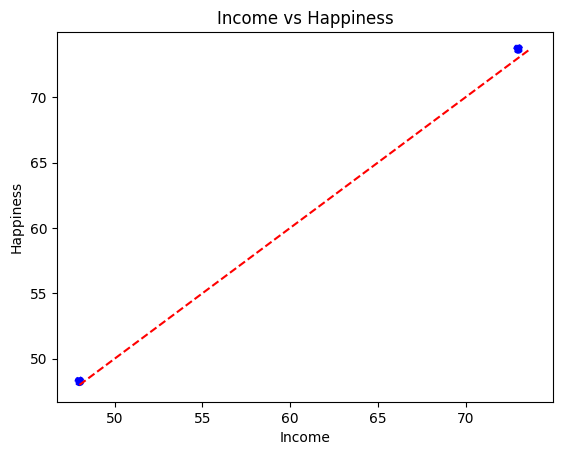

In [ ]:
plt.scatter(y_test,y_pred,color="blue",linestyle="--")
minimum = min(min(y_test),min(y_pred))
maximum = max(max(y_test),max(y_pred))
plt.plot([minimum,maximum],[minimum,maximum],color="red",linestyle="--")
plt.xlabel("Income")
plt.ylabel("Happiness")
plt.title("Income vs Happiness")
plt.show()

## **TASK 3-income and Salary**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [ ]:
df_income = pd.read_csv("income_data.csv")
df_salary = pd.read_csv("Salary_Data.csv")
df_income.head(10)

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398
5,6,3.729643,2.458556
6,7,4.674517,3.192992
7,8,4.498104,1.907137
8,9,3.121631,2.942450
9,10,4.639914,3.737942


In [ ]:
df_salary.head(10)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [ ]:
print(df_income.shape)
print(df_salary.shape)

(498, 3)
(30, 2)


In [ ]:
X_income = df_income[["income"]]
y_income = df_income["happiness"]

In [ ]:
X_salary = df_salary.drop("Salary",axis=1)
y_salary = df_salary["Salary"]

In [ ]:
X_train_income, X_test_income, y_train_income, y_test_income = train_test_split(X_income, y_income, test_size=0.2, random_state=42)

In [ ]:
X_train_salary, X_test_salary, y_train_salary, y_test_salary = train_test_split(X_salary, y_salary, test_size=0.2, random_state=42)

In [ ]:
model_income = LinearRegression()
model_salary = LinearRegression()
# Ensure X_train_income is a DataFrame
if isinstance(X_train_income, pd.Series):
    X_train_income = X_train_income.to_frame()
model_income.fit(X_train_income, y_train_income)
model_salary.fit(X_train_salary, y_train_salary)

LinearRegression()

In [ ]:
# Ensure X_test_income is a DataFrame with the correct column name for prediction
if isinstance(X_test_income, pd.Series):
    X_test_income = X_test_income.to_frame(name='income')
# Ensure X_test_salary is a DataFrame with the correct column name for prediction
if isinstance(X_test_salary, pd.Series):
    X_test_salary = X_test_salary.to_frame(name='YearsExperience')
y_pred_income = model_income.predict(X_test_income)
y_pred_salary = model_salary.predict(X_test_salary)

In [ ]:
#For the income Dataset_for finding best alpha
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV

model_income = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01,0.1,1,10,100]))
model_income.fit(X_train_income, y_train_income)

ridge_model = model_income.named_steps['ridgecv']
print("Best alpha:",ridge_model.alpha_)

y_pred_income = model_income.predict(X_test_income)

Best alpha: 0.1


In [ ]:
#For the income Dataset_apply the best alpha
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

#model_income = make_pipeline(StandardScaler(), Ridge(alpha=0.1))
model_income = Ridge(alpha=0.1)
model_income.fit(X_train_income, y_train_income)

y_pred_income = model_income.predict(X_test_income)

In [ ]:
print("INtercept",model_income.intercept_)
print("Slope",model_income.coef_[0])
print("Actual values",y_test_income.values)
print("Predicted values",y_pred_income)

INtercept 0.14196766239476988
Slope 0.7247098103936811
Actual values [4.75416839 4.1596093  2.29570014 2.31155424 2.86127444 1.96563593
 4.57080113 4.00453774 1.46061633 3.73794161 4.83350643 3.05738784
 3.06760945 2.78424454 2.15584332 2.96216821 2.23344058 6.29910126
 1.83980201 2.96195666 2.33627603 4.2452156  2.11513648 1.30848726
 4.71966533 0.77128657 2.67988732 4.98525493 3.80429886 4.8266027
 0.69845996 3.04079729 2.39167752 4.5993734  3.73056996 3.70343793
 0.96852733 3.45310274 1.41666106 1.41022957 5.83619666 4.3284171
 5.9142477  5.3139569  2.31448898 2.00904646 2.57505486 3.02072445
 2.20098217 0.26604366 3.98112774 3.22747217 5.26547896 4.93304409
 2.66611603 4.30728842 3.99041589 4.56870456 5.68375056 3.94101932
 4.32466038 1.92757883 5.15933124 4.08382116 2.45320906 4.68281699
 4.28430556 4.0564931  2.41338175 4.72098734 4.63344105 2.94753147
 1.77593255 2.20824052 0.54836519 4.21269734 4.25831153 5.03400379
 3.58387516 4.3213643  3.87278885 2.96732327 2.57693996 3.3427

In [ ]:
print("MAE_income",mean_absolute_error(y_test_income,y_pred_income))
print("MSE_income",mean_squared_error(y_test_income,y_pred_income))
print("RMSE_income",np.sqrt(mean_squared_error(y_test_income,y_pred_income)))
print("R2_income",r2_score(y_test_income,y_pred_income))

MAE_income 0.6269592580503607
MSE_income 0.590126964919888
RMSE_income 0.7681972174642967
R2_income 0.6662695142198494


In [ ]:
print("MAE_salary",mean_absolute_error(y_test_salary,y_pred_salary))
print("MSE_salary",mean_squared_error(y_test_salary,y_pred_salary))
print("RMSE_salary",np.sqrt(mean_squared_error(y_test_salary,y_pred_salary)))
print("R2_salary",r2_score(y_test_salary,y_pred_salary))

MAE_salary 6286.453830757749
MSE_salary 49830096.85590839
RMSE_salary 7059.04362190151
R2_salary 0.9024461774180497


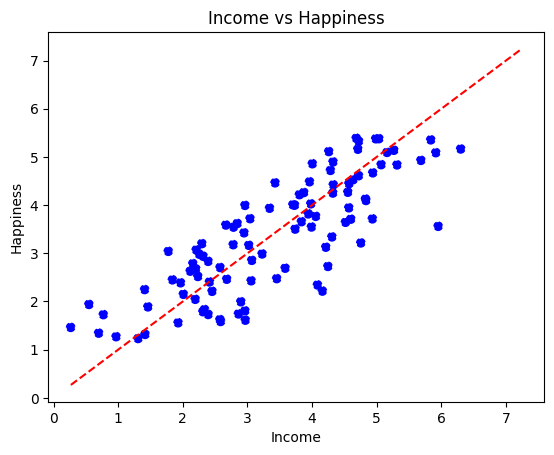

In [ ]:
plt.scatter(y_test_income,y_pred_income,color="blue",linestyle="--")
minimum = min(X_train_income.min().iloc[0], y_train_income.min())
maximum = max(X_test_income.max().iloc[0], y_test_income.max())
plt.plot([minimum,maximum],[minimum,maximum],color="red",linestyle="--")
plt.xlabel("Income")
plt.ylabel("Happiness")
plt.title("Income vs Happiness")
plt.show()

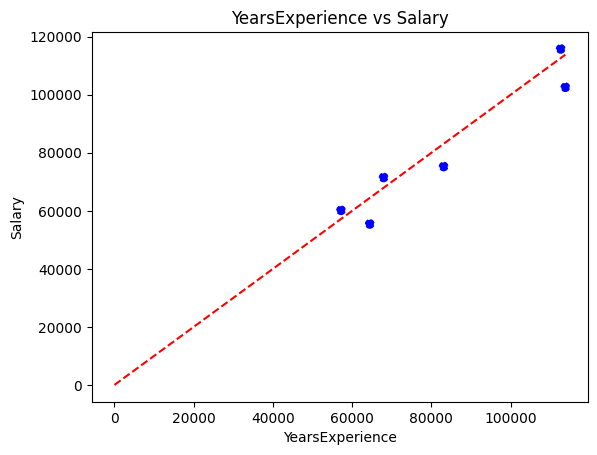

In [ ]:
plt.scatter(y_test_salary,y_pred_salary,color="blue",linestyle="--")
minimum = min(X_train_salary.min().iloc[0], y_train_salary.min())
maximum = max(X_test_salary.max().iloc[0], y_test_salary.max())
plt.plot([minimum,maximum],[minimum,maximum],color="red",linestyle="--")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("YearsExperience vs Salary")
plt.show()